In [1]:
import pandas as pd
import requests
import io

In [2]:
url = 'https://exoplanetarchive.ipac.caltech.edu/TAP/sync'
query = """
SELECT
pl_name,
hostname,
discoverymethod,
pl_masse,
pl_masseerr1,
pl_masseerr2,
pl_masselim,
pl_rade,
pl_radeerr1,
pl_radeerr2,
pl_radelim,
pl_dens,
pl_denserr1,
pl_denserr2,
pl_denslim,
pl_orbper,
pl_orbpererr1,
pl_orbpererr2,
pl_orbperlim,
pl_orbsmax,
pl_orbsmaxerr1,
pl_orbsmaxerr2,
pl_orbsmaxlim,
pl_orbeccen,
st_mass,
st_masserr1,
st_masserr2,
st_rad,
st_raderr1,
st_raderr2
FROM
pscomppars
"""
params = {
  'query': query,
  'format': 'csv'
}


In [3]:
import os

if not os.path.exists('./data'):
  os.makedirs('./data')

In [4]:
try:
  res = requests.get(url, params=params, timeout=30)
  res.raise_for_status()
  df = pd.read_csv(io.StringIO(res.text))
  df.to_csv("./data/pscomppars_v1.csv", index=False)
  print(df.sample(5))
except requests.exceptions.Timeout:
  print("Request timed out")
except requests.exceptions.HTTPError as e:
  print("Server error: ", e)
except Exception as e:
  print('Unexpected Error: ', e)

           pl_name    hostname  discoverymethod  pl_masse  pl_masseerr1  \
3462  Kepler-520 b  Kepler-520          Transit       NaN           NaN   
4464   HD 216520 c   HD 216520  Radial Velocity       NaN           NaN   
5015    TOI-2095 c    TOI-2095          Transit       7.4           NaN   
3274  Kepler-965 b  Kepler-965          Transit       NaN           NaN   
4965   HD 145457 b   HD 145457  Radial Velocity       NaN           NaN   

      pl_masseerr2  pl_masselim  pl_rade  pl_radeerr1  pl_radeerr2  ...  \
3462           NaN          NaN     1.66         0.28        -0.10  ...   
4464           NaN          NaN     3.03          NaN          NaN  ...   
5015           NaN          1.0     1.33         0.08        -0.08  ...   
3274           NaN          NaN     3.38         0.55        -0.39  ...   
4965           NaN          NaN    13.20          NaN          NaN  ...   

      pl_orbsmaxerr1  pl_orbsmaxerr2  pl_orbsmaxlim  pl_orbeccen  st_mass  \
3462         0.00196 

# Data Statistics
<ul>
<li>Shape</li>
<li>Data Types and info</li>
<li>Null values</li>
<li>Graphical Representation</li>
</ul>

In [5]:
df.shape

(6128, 30)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6128 entries, 0 to 6127
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6128 non-null   str    
 1   hostname         6128 non-null   str    
 2   discoverymethod  6128 non-null   str    
 3   pl_masse         2329 non-null   float64
 4   pl_masseerr1     2093 non-null   float64
 5   pl_masseerr2     2093 non-null   float64
 6   pl_masselim      2329 non-null   float64
 7   pl_rade          6078 non-null   float64
 8   pl_radeerr1      4212 non-null   float64
 9   pl_radeerr2      4212 non-null   float64
 10  pl_radelim       6078 non-null   float64
 11  pl_dens          5989 non-null   float64
 12  pl_denserr1      1402 non-null   float64
 13  pl_denserr2      1402 non-null   float64
 14  pl_denslim       5989 non-null   float64
 15  pl_orbper        5799 non-null   float64
 16  pl_orbpererr1    5307 non-null   float64
 17  pl_orbpererr2    5307 non

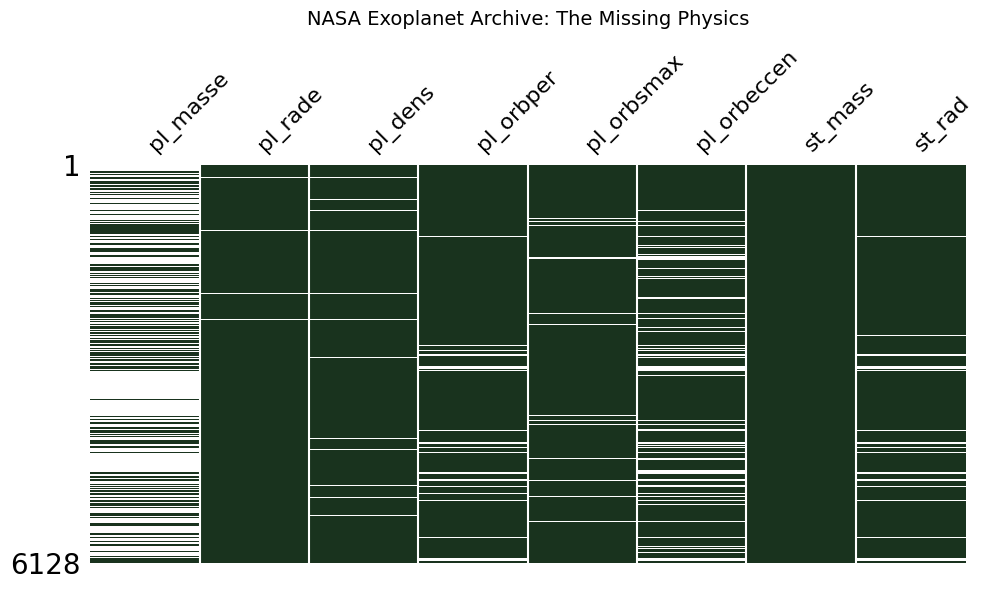

In [13]:
import missingno as msno
import matplotlib.pyplot as plt

df = pd.read_csv('data/pscomppars_v1.csv')
target_cols = ['pl_masse', 'pl_rade', 'pl_dens', 'pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'st_mass', 'st_rad']
df_subset = df[target_cols]

msno.matrix(df_subset, figsize=(10, 6), color=(0.1, 0.2, 0.12), sparkline=False)
plt.title("NASA Exoplanet Archive: The Missing Physics", fontsize=14, pad=15)
plt.tight_layout()

plt.show()